# LightGBM

Gradient boosting on the six selected ratios. They go in raw, with no WOE or capping, because tree splits only depend on the order of values. Trees are kept small, directions follow `RISK_TREND` (with `log_ta` left free), and the number of trees is chosen by cross-validation over years. Two Optuna searches then check whether other settings do better.

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
import optuna
import optuna.visualization.matplotlib as ovm
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

from src.data import load_data, split_by_year, year_folds
from src.features import add_ratios
from src.config import FEATURES, GBM_PARAMS, OPTUNA_STORAGE, RISK_TREND, SEED
from src.metrics import evaluate, paired_bootstrap
from src.gbm import cv_lgb, fit_lgb, feature_gain, monotone_constraints
from src.scorecard import WOEBinner
from src.benchmark import zpp_components, fit_caps, altman_zpp, ZScoreToPD

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

/Users/leomullins/GITREPOs/credit-risk/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train, val, test = (add_ratios(d) for d in split_by_year(load_data()))
splits = {"train": train, "val": val, "test": test}

## Settings

Monotone constraints: +1 means predicted PD can only rise with the feature, -1 only fall, 0 no rule.

In [3]:
pd.Series(monotone_constraints(FEATURES), index=FEATURES, name="constraint")

mve_tl   -1
tl_ta     1
ni_ta    -1
quick    -1
re_ta    -1
log_ta    0
Name: constraint, dtype: int64

In [4]:
pd.Series(GBM_PARAMS, name="value")

n_estimators         3000.00
learning_rate           0.02
num_leaves              7.00
min_child_samples     200.00
subsample               0.80
subsample_freq          1.00
reg_lambda              1.00
Name: value, dtype: float64

## Cross-validation by year

Folds are whole years: fit on every earlier year, check on the next two. Each fold stops early on its own check years. Only train years are used, so val and test stay untouched.

In [5]:
pd.DataFrame([
    {"fit": f"{f.year.min()}-{f.year.max()}", "fit_defaults": f.default.sum(),
     "check": f"{c.year.min()}-{c.year.max()}", "check_defaults": c.default.sum()}
    for f, c in year_folds(train)
])

,fit,fit_defaults,check,check_defaults
0,1999-2005,152,2006-2007,110
1,1999-2007,262,2008-2009,81
2,1999-2009,343,2010-2011,60


In [6]:
cv = cv_lgb(train, FEATURES)
cv.round(4)

,check_years,trees,n_pos,roc_auc,ks
0,2006-2007,212,110,0.8511,0.5849
1,2008-2009,373,81,0.9207,0.7146
2,2010-2011,279,60,0.9074,0.6858


In [7]:
cv["roc_auc"].agg(["mean", "std"]).round(4)

mean    0.8931
std     0.0369
Name: roc_auc, dtype: float64

The spread across folds is why settings are compared on CV rather than on one val set with 87 defaults. Per-fold scores are slightly optimistic, since each fold's check years also decided when to stop.

## Hyperparameter tuning

Optuna looks for settings that raise the mean AUC over the same year-based folds, so every search is measured against the current settings' score above. Val and test play no part.

Two searches:
- **3 settings**: tree size (`num_leaves`), minimum firm-years per leaf (`min_child_samples`) and shrinkage (`reg_lambda`).
- **11 settings**: those three plus row and feature sampling, extra shrinkage and smoothing, a minimum split gain, random split points, binning, and how strictly the monotone directions are enforced.

Both are stored in `optuna.db`; re-running the notebook only runs trials a search is still missing.

In [8]:
def cv_score(trial, params):
    """mean CV AUC for these settings; fold spread and tree count are kept on the trial"""
    folds = cv_lgb(train, FEATURES, {**GBM_PARAMS, **params})
    trial.set_user_attr("auc_std", folds["roc_auc"].std())
    trial.set_user_attr("trees", int(folds["trees"].median()))
    return folds["roc_auc"].mean()

In [9]:
def objective_small(trial):
    params = {
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 800, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 3, 31),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }
    return cv_score(trial, params)

In [10]:
def objective_full(trial):
    params = {
        # tree size and leaf rules
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 800, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 3, 31),
        "min_split_gain": trial.suggest_float("min_split_gain", 1e-3, 1, log=True),
        # shrinking leaf values
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "path_smooth": trial.suggest_float("path_smooth", 1e-3, 10, log=True),
        # randomness per tree (subsample_freq=1 stays from GBM_PARAMS)
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "extra_trees": trial.suggest_categorical("extra_trees", [True, False]),
        # binning and how strictly the monotone directions are enforced
        "max_bin": trial.suggest_categorical("max_bin", [63, 127, 255]),
        "monotone_constraints_method": trial.suggest_categorical(
            "monotone_constraints_method", ["basic", "intermediate", "advanced"]
        ),
    }
    return cv_score(trial, params)

In [11]:
STORAGE = OPTUNA_STORAGE   # repo root, whichever folder this runs from


def run_study(name, objective, n_trials):
    """load a stored study and run only the trials it is still missing"""
    study = optuna.create_study(
        study_name=name,
        storage=STORAGE,
        load_if_exists=True,
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    done = sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials)
    if done < n_trials:
        study.optimize(objective, n_trials=n_trials - done)
    return study


study_small = run_study("lgbm_small", objective_small, n_trials=30)
study_full = run_study("lgbm_cv_auc", objective_full, n_trials=100)   # the 11-setting search

In [12]:
rows = [{"search": "current settings", "trials": 0, "cv_auc": cv["roc_auc"].mean(),
         "fold_std": cv["roc_auc"].std(), "trees": int(cv["trees"].median())}]
for name, s in [("3 settings", study_small), ("11 settings", study_full)]:
    best = s.best_trial
    rows.append({"search": name, "trials": len(s.trials), "cv_auc": best.value,
                 "fold_std": best.user_attrs["auc_std"], "trees": best.user_attrs["trees"]})

summary = pd.DataFrame(rows).set_index("search")
summary["gain"] = summary["cv_auc"] - summary.loc["current settings", "cv_auc"]
summary.round(4)

,trials,cv_auc,fold_std,trees,gain
search,,,,,
current settings,0,0.8931,0.0369,279,0.0000
3 settings,30,0.8936,0.0353,250,0.0006
11 settings,100,0.8960,0.0325,1256,0.0029


In [13]:
pd.DataFrame({
    "current": pd.Series(GBM_PARAMS),
    "3 settings": pd.Series(study_small.best_params),
    "11 settings": pd.Series(study_full.best_params),
})

,current,3 settings,11 settings
colsample_bytree,NaN,NaN,0.970903
extra_trees,NaN,NaN,True
learning_rate,0.02,NaN,NaN
max_bin,NaN,NaN,127
min_child_samples,200.00,777.000000,55
min_split_gain,NaN,NaN,0.002298
monotone_constraints_method,NaN,NaN,basic
n_estimators,3000.00,NaN,NaN
num_leaves,7.00,20.000000,12
path_smooth,NaN,NaN,5.475695


Which of the eleven settings moved the score:

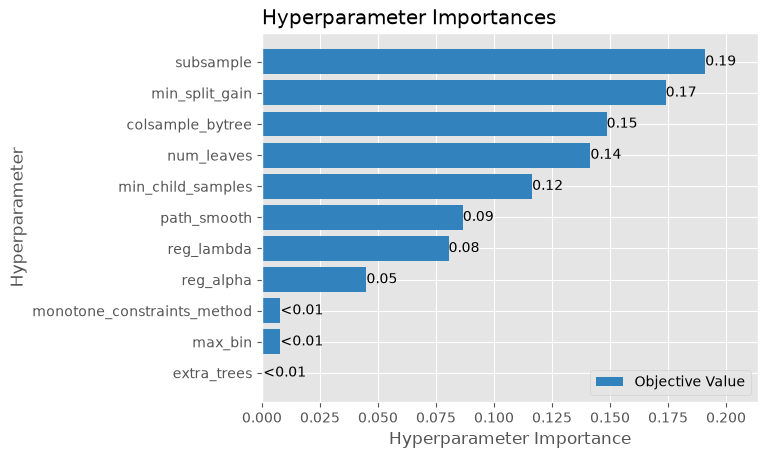

In [14]:
ovm.plot_param_importances(study_full);

Neither search clearly beats the current settings. The 3-setting search gained 0.0005 in mean CV AUC over 30 trials, and the 11-setting search gained 0.003 over 100. The 30 trials of the first search already spread by about 0.003, and the best of many trials is flattered by that much, so both gains are within noise. The current, simpler settings are kept: the model is not sensitive to these hyperparameters.

## Final model

The current settings are kept. Refit on all of train with the median number of trees from the CV and no early stopping.

In [15]:
n_trees = int(cv["trees"].median())
model = fit_lgb(train, None, FEATURES, {**GBM_PARAMS, "n_estimators": n_trees})
n_trees

279

In [16]:
pd.DataFrame({n: evaluate(d["default"], model.predict_proba(d[FEATURES])[:, 1]) for n, d in splits.items()}).round(4)

,train,val,test
n,55927.0000,10473.0000,12282.0000
n_pos,403.0000,87.0000,119.0000
base_rate,0.0072,0.0083,0.0097
pr_auc,0.0976,0.1801,0.1779
pr_auc_lift,13.5452,21.6804,18.3574
roc_auc,0.8850,0.9126,0.9248
brier,0.0068,0.0076,0.0088
brier_skill,0.0512,0.0732,0.0840
mean_pred,0.0072,0.0057,0.0070
ks,0.6231,0.7196,0.7329


Val played no part in fitting, so it is an out-of-time check alongside test. Mean predicted PD is 0.57% on val and 0.70% on test, against observed rates of 0.83% and 0.97%: the same under-prediction as the other models.

## Feature gain

Each feature's share of the total improvement from all splits.

In [17]:
feature_gain(model).round(3)

mve_tl    0.444
ni_ta     0.182
log_ta    0.134
quick     0.095
re_ta     0.082
tl_ta     0.063
dtype: float64

`mve_tl` carries 44% of the gain. `log_ta`, which added nothing to the scorecard, takes 13% here: left unconstrained, the trees use size in combination with the other ratios. `tl_ta` ranks last; it sits in the same correlation cluster as `mve_tl` (notebook 02), so most of what it says is already there.

## Against the scorecard and Z''

Both are rebuilt here, exactly as in notebooks 03 and 04, so all three models score the same test rows.

In [18]:
# Z'' benchmark (notebook 03)
caps = fit_caps(zpp_components(train))
z_map = ZScoreToPD().fit(altman_zpp(train, caps), train["default"])

# WOE scorecard (notebook 04)
binner = WOEBinner(RISK_TREND).fit(train, train["default"])
scorecard = LogisticRegression(max_iter=1000).fit(binner.transform(train), train["default"])

test_pd = {
    "z''": z_map.predict_proba(altman_zpp(test, caps)),
    "scorecard": scorecard.predict_proba(binner.transform(test))[:, 1],
    "lightgbm": model.predict_proba(test[FEATURES])[:, 1],
}
pd.DataFrame({name: evaluate(test["default"], p) for name, p in test_pd.items()}).round(4)

,z'',scorecard,lightgbm
n,12282.0000,12282.0000,12282.0000
n_pos,119.0000,119.0000,119.0000
base_rate,0.0097,0.0097,0.0097
pr_auc,0.0230,0.1031,0.1779
pr_auc_lift,2.3697,10.6456,18.3574
roc_auc,0.7731,0.9062,0.9248
brier,0.0096,0.0092,0.0088
brier_skill,-0.0001,0.0454,0.0840
mean_pred,0.0076,0.0069,0.0070
ks,0.5260,0.6791,0.7329


LightGBM leads on every ranking measure. The largest gain is at the risky end of the book: PR-AUC lift of 18.4, against 10.6 for the scorecard and 2.4 for Z''.

## Is the gap real?

With 119 test defaults, each model's AUC is uncertain on its own. A paired bootstrap resamples the test rows, scores **both** models on the same resample and records the difference. Both models face the same easy and hard firms in each resample, so the difference is far more stable than either score. If the 95% interval excludes zero, the gap is not luck.

In [19]:
rows = []
for metric, fn in [("roc_auc", roc_auc_score), ("pr_auc", average_precision_score)]:
    for a, b in [("lightgbm", "scorecard"), ("scorecard", "z''")]:
        diff, lo, hi = paired_bootstrap(test["default"], test_pd[a], test_pd[b], fn)
        rows.append({"metric": metric, "comparison": f"{a} - {b}", "diff": diff, "ci_low": lo, "ci_high": hi})
pd.DataFrame(rows).round(4)

,metric,comparison,diff,ci_low,ci_high
0,roc_auc,lightgbm - scorecard,0.0186,0.0082,0.0308
1,roc_auc,scorecard - z'',0.1332,0.1024,0.1624
2,pr_auc,lightgbm - scorecard,0.0747,0.0353,0.1272
3,pr_auc,scorecard - z'',0.0802,0.0528,0.1152


All four intervals exclude zero. LightGBM beats the scorecard by 0.019 AUC (95% interval 0.008 to 0.031) and by 0.075 PR-AUC (0.035 to 0.127). The scorecard beats Z'' by 0.133 AUC (0.102 to 0.162). The trade-off is 0.019 AUC for a model that cannot be read as a points table.